In [78]:
Subject='P1'

In [79]:
#统一时间戳并插值

import pandas as pd
import numpy as np
import glob
import os


def process_imu_fusion_perfect_sync(folder_path, output_filename=f'{Subject}_TimeAlign.csv'):
    file_list = glob.glob(os.path.join(folder_path, "*.csv"))
    if not file_list:
        print("未找到CSV文件！")
        return

    # 1. 扫描所有文件，确定全局时间锚点 (Global Anchor)
    # 我们需要找到所有文件中“最小”的那个时间戳，作为 t=0
    global_min_time = None
    global_max_time = None
    
    # 用于暂存读取的数据，避免重复IO
    raw_data_dict = {}

    print("Step 1: 扫描全局时间窗口...")
    for file in file_list:
        try:
            # 解析文件名
            filename = os.path.basename(file)
            parts = filename.split('_')
            sensor_id = parts[0] # S1, S2...
            
            # 识别类型
            filename_lower = filename.lower()
            if 'acc' in filename_lower: type_suffix = 'acc'
            elif 'gy' in filename_lower: type_suffix = 'gyro'
            else: continue

            # 读取
            df = pd.read_csv(file)
            df.columns = df.columns.str.strip()
            
            # 转为时间对象
            df['datetime'] = pd.to_datetime(df['epoc (ms)'], unit='ms')
            df = df.set_index('datetime').sort_index()
            # 去重
            df = df[~df.index.duplicated(keep='first')]

            # 更新全局范围
            t_start = df.index[0]
            t_end = df.index[-1]
            if global_min_time is None or t_start < global_min_time: global_min_time = t_start
            if global_max_time is None or t_end > global_max_time: global_max_time = t_end

            # 重命名列
            new_cols = {}
            for c in ['x-axis', 'y-axis', 'z-axis']:
                # 模糊匹配列名
                original_col = [col for col in df.columns if c in col]
                if original_col:
                    axis = c.split('-')[0] # x, y, z
                    new_cols[original_col[0]] = f"{sensor_id}_{type_suffix}_{axis}"
            
            df = df.rename(columns=new_cols)
            # 只保留数据列
            raw_data_dict[filename] = df[list(new_cols.values())]

        except Exception as e:
            print(f"Skipping {file}: {e}")

    print(f"全局时间起点: {global_min_time}")
    print(f"全局时间终点: {global_max_time}")

    # 2. 构建全局标准网格 (100Hz)
    # 无论传感器B何时启动，它都必须对齐到这个网格上
    target_index = pd.date_range(start=global_min_time, end=global_max_time, freq='10ms')
    final_df = pd.DataFrame(index=target_index)
    final_df.index.name = 'datetime'

    print("Step 2: 执行高精度对齐 (Resample & Interpolate)...")
    
    for fname, df in raw_data_dict.items():
        # --- 核心逻辑开始 ---
        
        # 场景：传感器B在 3.005s 启动，第一帧数据在 3.005s
        # 目标：我们需要 3.000s (空), 3.010s (插值值)
        
        # A. 将原始数据重新采样(Resample)或合并索引
        # 这里我们使用 union 索引法，保留原始的 3.005s 点，同时加入目标网格点
        combined_index = df.index.union(target_index)
        df_combined = df.reindex(combined_index)
        
        # B. 基于时间的插值
        # 这一步会利用 3.005s 的值和 3.015s 的值，计算出 3.010s 这个网格点的值
        # limit=10 防止长时间断联被错误连接，但在启动阶段这很重要
        # 注意：interpolate 默认不会向前填充 (not fill backward)，
        # 所以 3.005s 之前的所有网格点（比如 3.000s, 2.990s...）依然是 NaN。这正是我们想要的！
        df_interpolated = df_combined.interpolate(method='time', limit=100)
        
        # C. 抽取 (Downsample/Select)
        # 只取回落在 10ms 网格线上的点
        # 此时，3.005s 的原始数据被丢弃，留下了计算好的 3.010s 的值
        df_aligned = df_interpolated.reindex(target_index)
        
        # --- 核心逻辑结束 ---
        
        final_df = final_df.join(df_aligned)

    # 3. 整理输出
    final_df['epoc (ms)'] = (final_df.index.astype(np.int64) // 10**6)
    start_epoc = final_df.index[0]
    final_df['elapsed (s)'] = (final_df.index - start_epoc).total_seconds()
    final_df['timestamp'] = final_df.index.strftime('%Y-%m-%dT%H.%M.%S.%f').str[:-3]

    # 排序与导出
    cols = list(final_df.columns)
    # 简单把 timestamp 等放前面
    meta_cols = ['epoc (ms)', 'timestamp', 'elapsed (s)']
    data_cols = sorted([c for c in cols if c not in meta_cols])
    final_df = final_df[meta_cols + data_cols]
    
    # 统一保留3位小数
    final_df = final_df.round(3)

    final_df.to_csv(output_filename)
    print(f"处理完成: {output_filename}")

# 使用
#process_imu_fusion_perfect_sync(f'/mnt/ssd1/wyc/my_projects/SHRED/SHRED/Dataset_Stroke/Yan_Stroke Experiment Data/{Subject}/cane walking')
process_imu_fusion_perfect_sync(f'/mnt/ssd1/wyc/my_projects/SHRED/SHRED/Dataset_Stroke/Yan_Stroke Experiment Data/{Subject}/Without_cane')

Step 1: 扫描全局时间窗口...
全局时间起点: 2024-03-16 02:45:45.944000
全局时间终点: 2024-03-16 02:50:15.533000
Step 2: 执行高精度对齐 (Resample & Interpolate)...
处理完成: P1_TimeAlign.csv


In [80]:
#剔除没有没有全部6个IMU的时间戳

import pandas as pd
import numpy as np

# 1. 读取数据
# 假设你的文件名是 Merged_6IMU_PerfectSync.csv
df = pd.read_csv(f'{Subject}_TimeAlign.csv', index_col='datetime')

# ==========================================
# 【关键修复步骤】
# 强制将索引转换为 Datetime 对象
df.index = pd.to_datetime(df.index)
# ==========================================

# 2. 剔除包含空值的行 (掐头去尾)
df_clean = df.dropna(how='any')

print(f"清洗前形状: {df.shape}")
print(f"清洗后形状: {df_clean.shape}")

# 3. 重置 elapsed (s) 为从 0.000 开始
if not df_clean.empty:
    start_time = df_clean.index[0]
    
    # 使用 .copy() 防止警告
    df_clean = df_clean.copy()
    
    # 现在索引已经是时间格式了，可以正常相减
    # 除以 1秒 (pd.Timedelta) 将其转换为浮点数秒
    df_clean['elapsed (s)'] = (df_clean.index - start_time) / pd.Timedelta(seconds=1)
    
    # 保留3位小数
    df_clean['elapsed (s)'] = df_clean['elapsed (s)'].round(3)

    # 4. 导出
    output_filename = f'{Subject}_InitialAlign.csv'
    df_clean.to_csv(output_filename)
    print(f"处理完成！文件已保存为: {output_filename}")
else:
    print("错误：清洗后数据为空，请检查数据完整性。")

清洗前形状: (26959, 39)
清洗后形状: (26378, 39)
处理完成！文件已保存为: P1_InitialAlign.csv


In [81]:
import pandas as pd
import numpy as np
import warnings
from scipy.signal import butter, filtfilt
try:
    from ahrs.filters import Madgwick
    HAS_AHRS = True
except ImportError:
    Madgwick = None
    HAS_AHRS = False
    warnings.warn("ahrs is not installed. Falling back to static gravity-vector subtraction.")
import matplotlib.pyplot as plt

# --- 参数设置 ---
FS = 100     # 采样频率
CUTOFF = 10.0
G = 9.80665  # 重力加速度 (m/s^2)
GYRO_INPUT_UNIT = 'deg/s'  # 原始 gyroscope CSV 表头为 deg/s

# 读取前一步清理后的数据
# 注意：输出的 GravityFilter 文件现在包含 SI 单位的 filtered acc/gyro，
# 以及真正的 gravity-compensated linear acceleration。
df = pd.read_csv(f'{Subject}_InitialAlign.csv')
sensors = ['S1', 'S2', 'S3', 'S4', 'S5', 'S6']


def _elapsed_at(df, idx):
    """Return elapsed time at a positional index for logging."""
    if 'elapsed (s)' in df.columns and len(df) > 0:
        idx = int(np.clip(idx, 0, len(df) - 1))
        return float(df['elapsed (s)'].iloc[idx])
    return np.nan


def find_static_period(df, sensors, fs=100, min_duration_sec=3.0, step_sec=0.5, gyro_weight=0.01):
    """Find the most stable >=3 s static window across available IMUs."""
    window_len = int(round(fs * min_duration_sec))
    step_len = max(1, int(round(fs * step_sec)))

    usable_sensors = []
    for s in sensors:
        acc_cols = [f'{s}_acc_x', f'{s}_acc_y', f'{s}_acc_z']
        gyro_cols = [f'{s}_gyro_x', f'{s}_gyro_y', f'{s}_gyro_z']
        missing = [c for c in acc_cols + gyro_cols if c not in df.columns]
        if missing:
            warnings.warn(f'{s}: missing columns for static detection, skipped: {missing}')
            continue
        usable_sensors.append(s)

    if not usable_sensors:
        warnings.warn('No usable IMU columns found for static detection. Falling back to the first available rows.')
        end_idx = min(len(df), max(1, window_len))
        return 0, end_idx, df.iloc[:end_idx].copy(), np.nan

    if len(df) < window_len:
        warnings.warn(f'Data length ({len(df)}) is shorter than the requested static window ({window_len}). Using the full dataframe.')
        return 0, len(df), df.copy(), np.nan

    best = {'score': np.inf, 'start': 0, 'end': window_len}
    for start in range(0, len(df) - window_len + 1, step_len):
        end = start + window_len
        acc_norm_stds = []
        gyro_norm_means = []
        gyro_norm_stds = []

        for s in usable_sensors:
            acc = df.loc[df.index[start:end], [f'{s}_acc_x', f'{s}_acc_y', f'{s}_acc_z']].to_numpy(dtype=float)
            gyro = df.loc[df.index[start:end], [f'{s}_gyro_x', f'{s}_gyro_y', f'{s}_gyro_z']].to_numpy(dtype=float)
            if np.isnan(acc).all() or np.isnan(gyro).all():
                continue
            acc_norm = np.linalg.norm(acc, axis=1)
            gyro_norm = np.linalg.norm(gyro, axis=1)
            acc_norm_stds.append(np.nanstd(acc_norm))
            gyro_norm_means.append(np.nanmean(np.abs(gyro_norm)))
            gyro_norm_stds.append(np.nanstd(gyro_norm))

        if not acc_norm_stds or not gyro_norm_means:
            continue

        score = (np.nanmean(acc_norm_stds)
                 + gyro_weight * np.nanmean(gyro_norm_means)
                 + gyro_weight * np.nanmean(gyro_norm_stds))
        if np.isfinite(score) and score < best['score']:
            best = {'score': float(score), 'start': start, 'end': end}

    static_start_idx = best['start']
    static_end_idx = best['end']
    static_period = df.iloc[static_start_idx:static_end_idx].copy()

    print('=== Auto static period detection ===')
    print(f'usable sensors: {usable_sensors}')
    print(f'static index range: {static_start_idx} - {static_end_idx}')
    print(f'static elapsed range: {_elapsed_at(df, static_start_idx):.3f}s - {_elapsed_at(df, static_end_idx - 1):.3f}s')
    print(f'stability score: {best["score"]:.6f}')

    return static_start_idx, static_end_idx, static_period, best['score']


# ---------- 用重力对齐（只校正 roll/pitch，忽略 yaw） ----------
def align_to_gravity(acc_mean, g_world=np.array([0, 0, -1.0])):
    """Build a rotation matrix that aligns the static acceleration vector to gravity."""
    acc_mean = np.asarray(acc_mean, dtype=float)
    if not np.all(np.isfinite(acc_mean)) or np.linalg.norm(acc_mean) == 0:
        warnings.warn('Invalid static acceleration mean; using identity alignment.')
        return np.eye(3)

    acc_mean = acc_mean / np.linalg.norm(acc_mean)
    g_world = g_world / np.linalg.norm(g_world)
    v = np.cross(acc_mean, g_world)
    s = np.linalg.norm(v)
    c = np.clip(np.dot(acc_mean, g_world), -1.0, 1.0)
    if s < 1e-12:
        if c > 0:
            return np.eye(3)
        axis = np.array([1, 0, 0]) if abs(acc_mean[0]) < 0.9 else np.array([0, 1, 0])
        axis = axis / np.linalg.norm(axis)
        return -np.eye(3) + 2 * np.outer(axis, axis)

    # Rodrigues formula with K built from the raw cross-product vector v.
    # This keeps R_align orthonormal and preserves acceleration/gyro magnitudes.
    K = np.array([[0, -v[2], v[1]],
                  [v[2], 0, -v[0]],
                  [-v[1], v[0], 0]])
    R_align = np.eye(3) + K + K @ K * ((1 - c) / (s**2))
    return R_align


def calibrate_and_align(df, sensor_prefix, static_period):
    """Remove gyro bias and align acc/gyro axes using the detected static period."""
    acc_cols = [f'{sensor_prefix}_acc_x', f'{sensor_prefix}_acc_y', f'{sensor_prefix}_acc_z']
    gyro_cols = [f'{sensor_prefix}_gyro_x', f'{sensor_prefix}_gyro_y', f'{sensor_prefix}_gyro_z']
    missing = [c for c in acc_cols + gyro_cols if c not in df.columns]
    if missing:
        warnings.warn(f'{sensor_prefix}: missing columns for bias removal/alignment, skipped: {missing}')
        return df

    # gyro 去偏置，bias 来自自动检测到的静止阶段
    for col in gyro_cols:
        bias = static_period[col].mean()
        df[col] = df[col] - bias

    # 静止阶段平均加速度估计重力方向
    acc_mean = static_period[acc_cols].mean().to_numpy(dtype=float)
    R_align = align_to_gravity(acc_mean, np.array([0, 0, -1.0]))

    # 对整个序列 acc 和 gyro 做同样的 roll/pitch 对齐，保留原有处理逻辑
    df.loc[:, acc_cols] = df[acc_cols].to_numpy(dtype=float) @ R_align.T
    df.loc[:, gyro_cols] = df[gyro_cols].to_numpy(dtype=float) @ R_align.T
    return df


def butter_lowpass_filter(data, cutoff, fs, order=4):
    """Apply low-pass filtering with NaN interpolation and short-signal fallback."""
    series = pd.Series(data, dtype='float64').interpolate(limit_direction='both')
    values = series.to_numpy(dtype=float)
    if len(values) == 0:
        return values
    if np.isnan(values).any():
        warnings.warn('Filter input still contains NaN after interpolation; returning unfiltered values.')
        return values

    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    padlen = 3 * max(len(a), len(b))
    if len(values) <= padlen:
        warnings.warn(f'Signal too short for filtfilt (n={len(values)}, padlen={padlen}); returning unfiltered values.')
        return values
    return filtfilt(b, a, values)


def _acc_input_unit_from_static(static_acc_values):
    """Infer whether acceleration columns are in g or m/s^2 from a static segment."""
    static_norm = np.nanmedian(np.linalg.norm(static_acc_values, axis=1))
    if np.isfinite(static_norm) and static_norm < 3.0:
        return 'g'
    return 'm/s^2'


def _acc_to_mps2(acc_values, static_acc_values):
    """Convert acceleration arrays or single-axis signals to m/s^2."""
    acc_unit = _acc_input_unit_from_static(static_acc_values)
    if acc_unit == 'g':
        return acc_values * G, acc_unit
    return acc_values, acc_unit


def _gyro_to_rads(gyro_values):
    """Convert gyroscope data to rad/s using the source CSV unit."""
    if GYRO_INPUT_UNIT.lower() in ['deg/s', 'dps', 'degree/s', 'degrees/s']:
        return np.deg2rad(gyro_values), 'deg/s'
    return gyro_values, 'rad/s'


def _quaternion_from_two_vectors(v_from, v_to):
    """Quaternion [w, x, y, z] rotating v_from onto v_to."""
    v_from = np.asarray(v_from, dtype=float)
    v_to = np.asarray(v_to, dtype=float)
    v_from = v_from / np.linalg.norm(v_from)
    v_to = v_to / np.linalg.norm(v_to)
    dot = np.clip(np.dot(v_from, v_to), -1.0, 1.0)

    if dot < -0.999999:
        axis = np.array([1.0, 0.0, 0.0]) if abs(v_from[0]) < 0.9 else np.array([0.0, 1.0, 0.0])
        axis = axis - v_from * np.dot(v_from, axis)
        axis = axis / np.linalg.norm(axis)
        return np.array([0.0, axis[0], axis[1], axis[2]])

    q_xyz = np.cross(v_from, v_to)
    q = np.array([1.0 + dot, q_xyz[0], q_xyz[1], q_xyz[2]])
    return q / np.linalg.norm(q)


def _gravity_from_quaternion(Q):
    """Return gravity vector in the sensor/aligned frame from ahrs quaternions."""
    qw, qx, qy, qz = Q[:, 0], Q[:, 1], Q[:, 2], Q[:, 3]
    gravity_unit = np.column_stack([
        2.0 * (qx * qz - qw * qy),
        2.0 * (qw * qx + qy * qz),
        2.0 * (0.5 - qx**2 - qy**2)
    ])
    return gravity_unit * G


def estimate_orientation_and_remove_gravity(df, sensor, static_period, fs=100):
    """Estimate IMU orientation and write gravity-compensated linear acceleration columns."""
    acc_cols = [f'{sensor}_acc_x', f'{sensor}_acc_y', f'{sensor}_acc_z']
    gyro_cols = [f'{sensor}_gyro_x', f'{sensor}_gyro_y', f'{sensor}_gyro_z']
    linacc_cols = [f'{sensor}_linacc_x', f'{sensor}_linacc_y', f'{sensor}_linacc_z']
    missing = [c for c in acc_cols + gyro_cols if c not in df.columns]
    if missing:
        warnings.warn(f'{sensor}: missing columns for gravity compensation, skipped: {missing}')
        return df

    acc_values = df[acc_cols].to_numpy(dtype=float)
    static_acc_values = static_period[acc_cols].to_numpy(dtype=float)
    acc_ms2, acc_unit = _acc_to_mps2(acc_values, static_acc_values)

    gyro_values = df[gyro_cols].to_numpy(dtype=float)
    gyro_rads, gyro_unit = _gyro_to_rads(gyro_values)

    static_acc_ms2 = static_period[acc_cols].to_numpy(dtype=float)
    static_acc_ms2, _ = _acc_to_mps2(static_acc_ms2, static_acc_ms2)
    static_acc_mean = np.nanmean(static_acc_ms2, axis=0)
    if not np.all(np.isfinite(static_acc_mean)) or np.linalg.norm(static_acc_mean) == 0:
        warnings.warn(f'{sensor}: invalid static acceleration for gravity compensation, skipped.')
        return df

    q0 = _quaternion_from_two_vectors(np.array([0.0, 0.0, 1.0]), static_acc_mean)

    if HAS_AHRS:
        Q = np.zeros((len(df), 4), dtype=float)
        Q[0] = q0
        madgwick = Madgwick(frequency=fs)
        for i in range(1, len(df)):
            if np.all(np.isfinite(gyro_rads[i])) and np.all(np.isfinite(acc_ms2[i])):
                Q[i] = madgwick.updateIMU(Q[i - 1], gyr=gyro_rads[i], acc=acc_ms2[i])
            else:
                Q[i] = Q[i - 1]
        gravity_sensor = _gravity_from_quaternion(Q)
        method = 'Madgwick IMU'
    else:
        gravity_sensor = np.tile(static_acc_mean, (len(df), 1))
        method = 'static gravity vector fallback'

    linacc = acc_ms2 - gravity_sensor

    # 去除静止阶段残余均值，保证静止期 linear acceleration 接近 0
    static_idx = static_period.index.to_numpy()
    residual = np.nanmean(linacc[static_idx, :], axis=0)
    linacc = linacc - residual

    df.loc[:, linacc_cols] = linacc
    static_mean = df.loc[static_idx, linacc_cols].mean().to_numpy(dtype=float)
    print(f'{sensor}: gravity compensation = {method}; acc unit={acc_unit}, gyro unit={gyro_unit}; '
          f'static linacc mean [m/s^2] = {np.round(static_mean, 4)}')
    return df


# ---------- 自动寻找静止阶段 ----------
static_start_idx, static_end_idx, static_period, static_score = find_static_period(
    df, sensors, fs=FS, min_duration_sec=3.0
)
static_summary = {
    'start_idx': static_start_idx,
    'end_idx': static_end_idx,
    'start_elapsed': _elapsed_at(df, static_start_idx),
    'end_elapsed': _elapsed_at(df, static_end_idx - 1),
    'score': static_score,
}

# ---------- gyro bias 去除 + 重力方向对齐 ----------
for s in sensors:
    df = calibrate_and_align(df, s, static_period)

# 对齐后的静止阶段，用于 Madgwick 初始姿态和 linacc 静止残差校正
static_period_aligned = df.iloc[static_start_idx:static_end_idx].copy()

# ---------- 低通滤波：输出 SI 单位的 acc/gyro filtered 列 ----------
for s in sensors:
    acc_candidates = [f'{s}_acc_x', f'{s}_acc_y', f'{s}_acc_z']
    gyro_candidates = [f'{s}_gyro_x', f'{s}_gyro_y', f'{s}_gyro_z']
    filter_candidates = acc_candidates + gyro_candidates
    missing = [c for c in filter_candidates if c not in df.columns]
    if missing:
        warnings.warn(f'{s}: missing columns during acc/gyro filtering, skipped missing columns: {missing}')

    static_acc_values = None
    if all(c in static_period_aligned.columns for c in acc_candidates):
        static_acc_values = static_period_aligned[acc_candidates].to_numpy(dtype=float)
        acc_input_unit = _acc_input_unit_from_static(static_acc_values)
    else:
        acc_input_unit = 'unknown'
        warnings.warn(f'{s}: cannot infer acc unit from static period; acc filtered columns will be left unchanged.')

    gyro_input_unit = GYRO_INPUT_UNIT
    acc_written = False
    gyro_written = False
    for src in filter_candidates:
        if src not in df.columns:
            continue
        filtered_values = butter_lowpass_filter(df[src].values, CUTOFF, FS)
        if src in acc_candidates:
            if static_acc_values is not None:
                filtered_values, acc_input_unit = _acc_to_mps2(filtered_values, static_acc_values)
            acc_written = True
        elif src in gyro_candidates:
            filtered_values, gyro_input_unit = _gyro_to_rads(filtered_values)
            gyro_written = True
        df[f'{src}_filtered'] = filtered_values

    acc_msg = f'filtered acc saved in m/s^2 (input {acc_input_unit})' if acc_written else 'filtered acc columns missing'
    gyro_msg = f'filtered gyro saved in rad/s (input {gyro_input_unit})' if gyro_written else 'filtered gyro columns missing'
    print(f'{s}: {acc_msg}; {gyro_msg}.')

# ---------- 真正执行重力补偿，输出 linear acceleration ----------
for s in sensors:
    df = estimate_orientation_and_remove_gravity(df, s, static_period_aligned, fs=FS)

# ---------- linear acceleration 低通滤波 ----------
for s in sensors:
    linacc_candidates = [f'{s}_linacc_x', f'{s}_linacc_y', f'{s}_linacc_z']
    missing = [c for c in linacc_candidates if c not in df.columns]
    if missing:
        warnings.warn(f'{s}: missing linacc columns during filtering, skipped: {missing}')
    for src in linacc_candidates:
        if src in df.columns:
            df[f'{src}_filtered'] = butter_lowpass_filter(df[src].values, CUTOFF, FS)

output_filename = f'{Subject}_GravityFilter.csv'
df.to_csv(output_filename, index=False)
print(f'处理完成，数据已保存: {output_filename}')
print('说明：S*_acc_*_filtered 已转换为 m/s^2；S*_gyro_*_filtered 已转换为 rad/s；S*_linacc_*_filtered 为 m/s^2。')


=== Auto static period detection ===
usable sensors: ['S1', 'S2', 'S3', 'S4', 'S5', 'S6']
static index range: 9050 - 9350
static elapsed range: 90.500s - 93.490s
stability score: 0.026109
S1: filtered acc saved in m/s^2 (input g); filtered gyro saved in rad/s (input deg/s).
S2: filtered acc saved in m/s^2 (input g); filtered gyro saved in rad/s (input deg/s).
S3: filtered acc saved in m/s^2 (input g); filtered gyro saved in rad/s (input deg/s).
S4: filtered acc saved in m/s^2 (input g); filtered gyro saved in rad/s (input deg/s).
S5: filtered acc saved in m/s^2 (input g); filtered gyro saved in rad/s (input deg/s).
S6: filtered acc saved in m/s^2 (input g); filtered gyro saved in rad/s (input deg/s).
S1: gravity compensation = Madgwick IMU; acc unit=g, gyro unit=deg/s; static linacc mean [m/s^2] = [ 0. -0.  0.]
S2: gravity compensation = Madgwick IMU; acc unit=g, gyro unit=deg/s; static linacc mean [m/s^2] = [-0.  0.  0.]
S3: gravity compensation = Madgwick IMU; acc unit=g, gyro unit=d

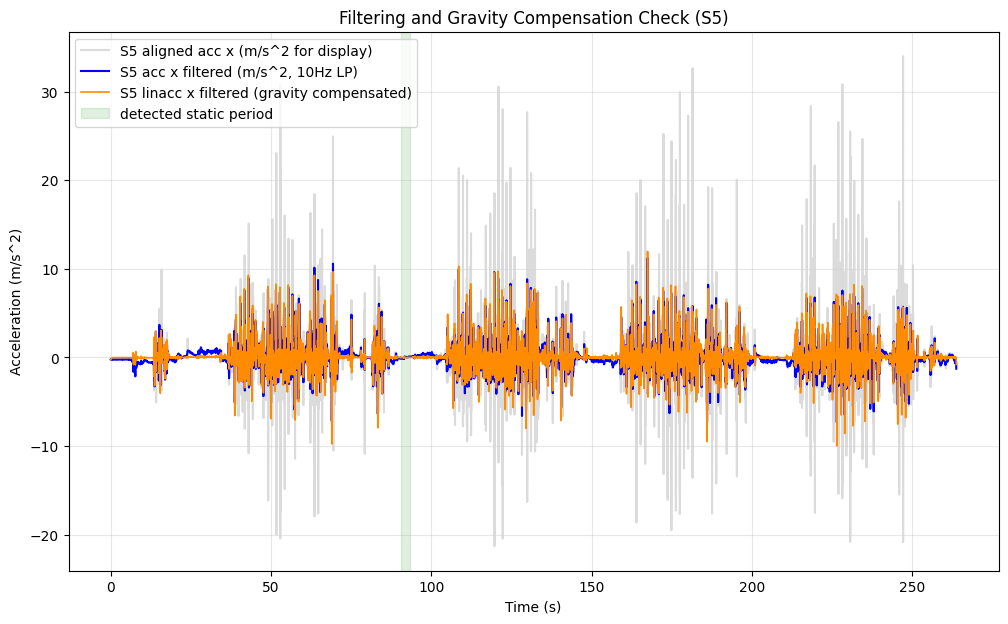

In [82]:
# 滤波与重力补偿效果可视化
plot_sensor = 'S5'
if f'{plot_sensor}_acc_x' not in df.columns:
    available = [s for s in sensors if f'{s}_acc_x' in df.columns]
    plot_sensor = available[0] if available else None

if plot_sensor is None:
    print('没有可绘制的 acc 数据。')
else:
    plt.figure(figsize=(12, 7))
    start_idx, end_idx = 0, min(40000, len(df))
    time_plot = df['elapsed (s)'].iloc[start_idx:end_idx] if 'elapsed (s)' in df.columns else np.arange(start_idx, end_idx) / FS

    raw_acc_plot = df[f'{plot_sensor}_acc_x'].iloc[start_idx:end_idx].to_numpy(dtype=float)
    if (
        'static_period_aligned' in globals()
        and '_acc_to_mps2' in globals()
        and all(c in static_period_aligned.columns for c in [f'{plot_sensor}_acc_x', f'{plot_sensor}_acc_y', f'{plot_sensor}_acc_z'])
    ):
        raw_acc_plot, _ = _acc_to_mps2(
            raw_acc_plot,
            static_period_aligned[[f'{plot_sensor}_acc_x', f'{plot_sensor}_acc_y', f'{plot_sensor}_acc_z']].to_numpy(dtype=float)
        )

    plt.plot(time_plot, raw_acc_plot,
             label=f'{plot_sensor} aligned acc x (m/s^2 for display)', color='lightgray', alpha=0.8)
    if f'{plot_sensor}_acc_x_filtered' in df.columns:
        plt.plot(time_plot, df[f'{plot_sensor}_acc_x_filtered'].iloc[start_idx:end_idx],
                 label=f'{plot_sensor} acc x filtered (m/s^2, 10Hz LP)', color='blue', linewidth=1.5)
    if f'{plot_sensor}_linacc_x_filtered' in df.columns:
        plt.plot(time_plot, df[f'{plot_sensor}_linacc_x_filtered'].iloc[start_idx:end_idx],
                 label=f'{plot_sensor} linacc x filtered (gravity compensated)', color='darkorange', linewidth=1.2)

    if 'static_summary' in globals():
        plt.axvspan(static_summary['start_elapsed'], static_summary['end_elapsed'],
                    color='green', alpha=0.12, label='detected static period')

    plt.title(f'Filtering and Gravity Compensation Check ({plot_sensor})')
    plt.xlabel('Time (s)')
    plt.ylabel('Acceleration (m/s^2)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


数据加载成功。
=== Cane usage detection by S6 ===
features: ['S6 linacc norm', '0.573 * S6 gyro norm (rad/s)']
split index: 23737
split elapsed time: 237.370s
first part S6 intensity: 0.080217 -> without_cane
second part S6 intensity: 0.611164 -> with_cane
with cane part: second
Cane labels 已写回: P1_GravityFilter.csv
=== Gait session cane statistics ===
总 session 数: 3
with cane session 数: 0
without cane session 数: 3
mixed session 数: 0
=== 保存前检查 ===
数据框行数: 3104
数据框列数: 117
Session数量: 3
with cane session 数: 0
without cane session 数: 3
mixed session 数: 0

=== 保存后验证 ===
CSV文件行数: 3104
CSV文件Session数量: 3
成功！提取的步态片段已保存至: P1_Gait_xyzShank.csv
包含 Session 数量: 3
开始绘图...提取到 3 个片段


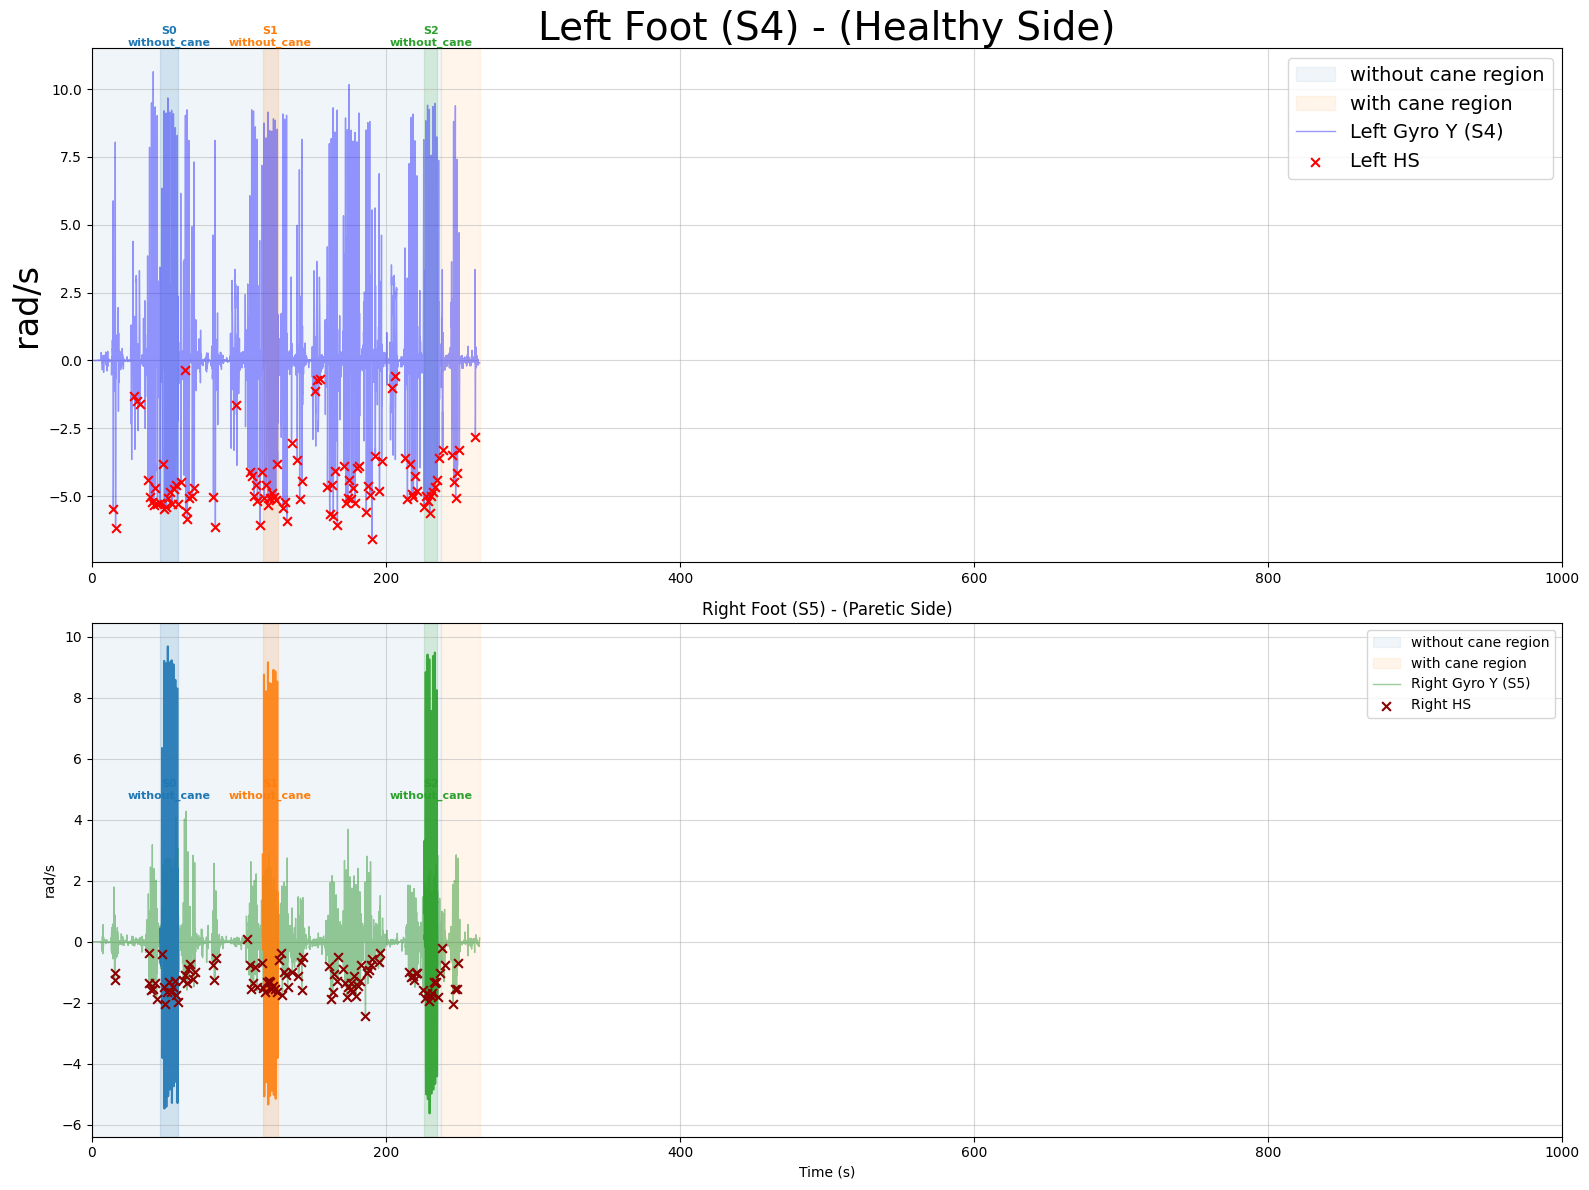

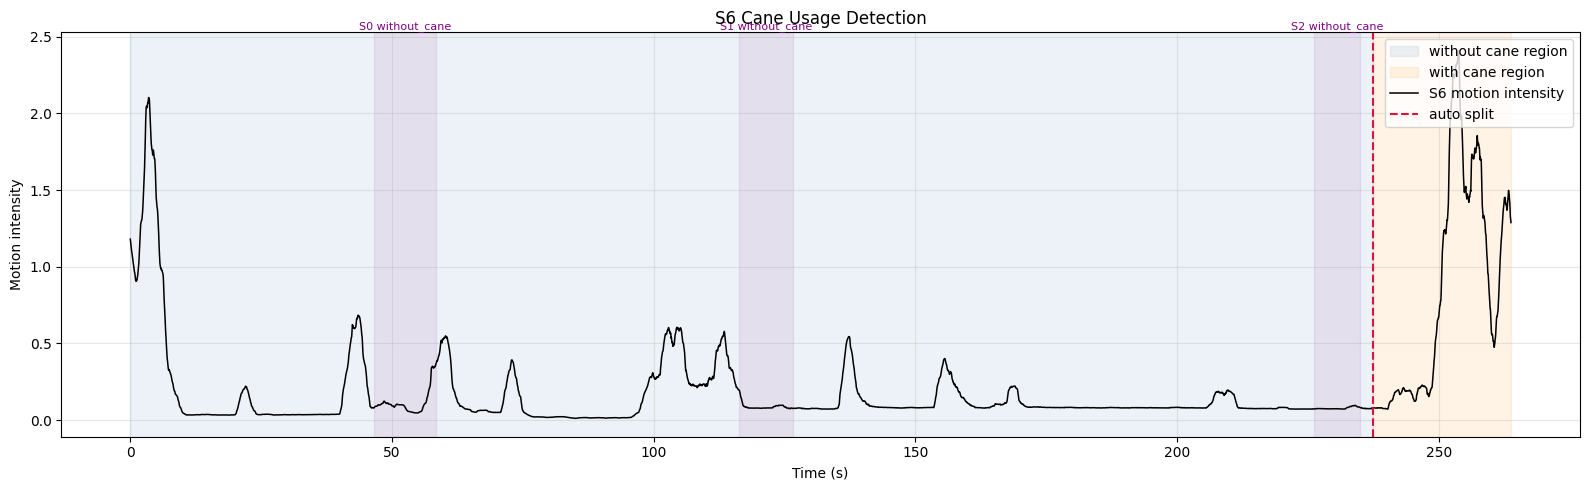

In [83]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

GYRO_STRAIGHT_THRESHOLD_RAD = np.deg2rad(15.0)
GYRO_MOTION_WEIGHT_RAD = 0.01 * 180.0 / np.pi  # match previous 0.01 * deg/s scale

# ==========================================
# 1. 基于 S6 自动判断 cane 使用区间
# ==========================================
def detect_cane_usage_by_s6(df, fs=100):
    """Split the recording into two parts and label cane use from S6 motion intensity."""
    df = df.copy()
    gyro_cols = ['S6_gyro_x_filtered', 'S6_gyro_y_filtered', 'S6_gyro_z_filtered']
    linacc_cols = ['S6_linacc_x_filtered', 'S6_linacc_y_filtered', 'S6_linacc_z_filtered']
    acc_cols = ['S6_acc_x_filtered', 'S6_acc_y_filtered', 'S6_acc_z_filtered']

    has_gyro = all(c in df.columns for c in gyro_cols)
    has_linacc = all(c in df.columns for c in linacc_cols)
    has_acc = all(c in df.columns for c in acc_cols)

    if not has_gyro and not has_linacc and not has_acc:
        warnings.warn('S6 motion columns are missing. Cane_Use and Cane_Label are set to NaN.')
        df['Cane_Use'] = np.nan
        df['Cane_Label'] = pd.Series(index=df.index, dtype='object')
        return df, None, {
            'warning': 'missing_s6_motion_columns',
            'split_idx': None,
            'split_elapsed': np.nan,
            'first_intensity': np.nan,
            'second_intensity': np.nan,
            'with_cane_part': 'unknown'
        }

    features = []
    feature_names = []
    if has_linacc:
        linacc_norm = np.linalg.norm(df[linacc_cols].to_numpy(dtype=float), axis=1)
        features.append(linacc_norm)
        feature_names.append('S6 linacc norm')
    elif has_acc:
        acc_values = df[acc_cols].to_numpy(dtype=float)
        acc_smooth = pd.DataFrame(acc_values).rolling(window=max(1, int(fs * 2)), center=True, min_periods=1).mean().to_numpy()
        acc_dyn_norm = np.linalg.norm(acc_values - acc_smooth, axis=1)
        features.append(acc_dyn_norm)
        feature_names.append('S6 dynamic acc norm')

    if has_gyro:
        gyro_norm = np.linalg.norm(df[gyro_cols].to_numpy(dtype=float), axis=1)
        features.append(GYRO_MOTION_WEIGHT_RAD * gyro_norm)
        feature_names.append(f'{GYRO_MOTION_WEIGHT_RAD:.3f} * S6 gyro norm (rad/s)')

    motion_intensity = np.nansum(np.vstack(features), axis=0)
    motion_intensity = pd.Series(motion_intensity).interpolate(limit_direction='both')
    smooth_window = max(1, int(fs * 2.0))
    motion_intensity_smooth = motion_intensity.rolling(window=smooth_window, center=True, min_periods=1).mean()
    df['S6_motion_intensity'] = motion_intensity_smooth.to_numpy(dtype=float)

    n = len(df)
    if n < 2:
        warnings.warn('Data is too short for cane split detection. Cane labels set to NaN.')
        df['Cane_Use'] = np.nan
        df['Cane_Label'] = pd.Series(index=df.index, dtype='object')
        return df, None, {'warning': 'too_short', 'split_idx': None, 'split_elapsed': np.nan}

    min_part_len = max(int(fs * 10), int(0.10 * n))
    if 2 * min_part_len >= n:
        candidates = [n // 2]
    else:
        step = max(1, int(fs * 1.0))
        candidates = range(min_part_len, n - min_part_len + 1, step)

    best_split = n // 2
    best_score = -np.inf
    for split_idx in candidates:
        first = motion_intensity_smooth.iloc[:split_idx].dropna()
        second = motion_intensity_smooth.iloc[split_idx:].dropna()
        if first.empty or second.empty:
            continue
        first_val = float(first.median())
        second_val = float(second.median())
        balance = min(len(first), len(second)) / max(len(first), len(second))
        score = abs(first_val - second_val) * (0.5 + 0.5 * balance)
        if score > best_score:
            best_score = score
            best_split = int(split_idx)

    split_idx = best_split
    first_intensity = float(motion_intensity_smooth.iloc[:split_idx].median())
    second_intensity = float(motion_intensity_smooth.iloc[split_idx:].median())

    first_is_cane = first_intensity > second_intensity
    first_use = 1 if first_is_cane else 0
    second_use = 0 if first_is_cane else 1
    first_label = 'with_cane' if first_use == 1 else 'without_cane'
    second_label = 'with_cane' if second_use == 1 else 'without_cane'

    df['Cane_Use'] = np.nan
    df['Cane_Label'] = pd.Series(index=df.index, dtype='object')
    use_col = df.columns.get_loc('Cane_Use')
    label_col = df.columns.get_loc('Cane_Label')
    df.iloc[:split_idx, use_col] = first_use
    df.iloc[:split_idx, label_col] = first_label
    df.iloc[split_idx:, use_col] = second_use
    df.iloc[split_idx:, label_col] = second_label

    split_elapsed = float(df['elapsed (s)'].iloc[split_idx]) if 'elapsed (s)' in df.columns and split_idx < len(df) else split_idx / fs
    cane_part_info = {
        'feature_names': feature_names,
        'split_idx': split_idx,
        'split_elapsed': split_elapsed,
        'first_intensity': first_intensity,
        'second_intensity': second_intensity,
        'first_label': first_label,
        'second_label': second_label,
        'with_cane_part': 'first' if first_is_cane else 'second',
        'without_cane_part': 'second' if first_is_cane else 'first',
        'split_score': float(best_score),
    }

    print('=== Cane usage detection by S6 ===')
    print(f'features: {feature_names}')
    print(f'split index: {split_idx}')
    print(f'split elapsed time: {split_elapsed:.3f}s')
    print(f'first part S6 intensity: {first_intensity:.6f} -> {first_label}')
    print(f'second part S6 intensity: {second_intensity:.6f} -> {second_label}')
    print(f'with cane part: {cane_part_info["with_cane_part"]}')

    return df, split_idx, cane_part_info


# ==========================================
# 2. 核心逻辑：数据加载与提取
# ==========================================
def _label_session_by_cane(sess_df):
    """Assign per-session cane label by majority vote within the session."""
    sess_df = sess_df.copy()
    if 'Cane_Use' not in sess_df.columns:
        warnings.warn('Cane_Use is missing in a session. Session cane labels set to NaN.')
        sess_df['Cane_Use'] = np.nan
        sess_df['Cane_Label'] = pd.Series(index=sess_df.index, dtype='object')
        sess_df['Cane_Mixed'] = np.nan
        return sess_df

    cane_values = sess_df['Cane_Use'].dropna()
    if cane_values.empty:
        session_use = np.nan
        session_label = np.nan
        mixed = np.nan
    else:
        cane_values = cane_values.astype(int)
        mixed = int(cane_values.nunique() > 1)
        session_use = int(cane_values.value_counts().idxmax())
        session_label = 'with_cane' if session_use == 1 else 'without_cane'

    sess_df['Cane_Use'] = session_use
    sess_df['Cane_Label'] = session_label
    sess_df['Cane_Mixed'] = mixed
    return sess_df


def summarize_session_cane_stats(df_sessions):
    """Summarize session counts by cane label."""
    if df_sessions.empty or 'Session_ID' not in df_sessions.columns:
        return {'total': 0, 'with_cane': 0, 'without_cane': 0, 'mixed': 0}

    session_summary = df_sessions.groupby('Session_ID', as_index=False).agg(
        Cane_Use=('Cane_Use', 'first'),
        Cane_Label=('Cane_Label', 'first'),
        Cane_Mixed=('Cane_Mixed', 'first')
    )
    return {
        'total': int(len(session_summary)),
        'with_cane': int((session_summary['Cane_Use'] == 1).sum()),
        'without_cane': int((session_summary['Cane_Use'] == 0).sum()),
        'mixed': int((session_summary['Cane_Mixed'] == 1).sum()),
    }


def extract_by_healthy_side(df, healthy_side_prefix='S5', min_cycles=5, fs=100):
    """
    仅根据健康侧足部信号划分步态周期；每个 session 追加 cane 标签。
    """
    df = df.copy()
    if 'Cane_Use' not in df.columns or 'Cane_Label' not in df.columns:
        warnings.warn('Cane labels are missing before gait extraction. Filling with NaN.')
        df['Cane_Use'] = np.nan
        df['Cane_Label'] = pd.Series(index=df.index, dtype='object')

    gyro_col = f'{healthy_side_prefix}_gyro_x_filtered'
    if gyro_col not in df.columns:
        warnings.warn(f'{gyro_col} is missing. Cannot extract gait sessions.')
        return pd.DataFrame()

    gyro_vals = df[gyro_col].to_numpy(dtype=float)
    if len(gyro_vals) == 0 or np.nanstd(gyro_vals) == 0:
        warnings.warn('Healthy-side gyro signal is empty or flat. Cannot extract gait sessions.')
        return pd.DataFrame()

    # --- A. 检测健康侧 HS ---
    peaks, _ = find_peaks(gyro_vals, height=np.nanstd(gyro_vals) * 1.5, distance=fs * 0.6)

    hs_indices = []
    for p in peaks:
        window = gyro_vals[p : p + int(fs * 0.5)]
        if len(window) > 0 and not np.isnan(window).all():
            hs_indices.append(p + np.nanargmin(window))
    hs_indices = np.array(hs_indices, dtype=int)

    # --- B. 直线段与连续性筛选 ---
    straight_col = 'S3_gyro_z_filtered'
    if straight_col in df.columns:
        gyro_z_smooth = df[straight_col].rolling(window=fs * 2, center=True, min_periods=1).mean().abs()
        is_straight = gyro_z_smooth < GYRO_STRAIGHT_THRESHOLD_RAD
    else:
        warnings.warn(f'{straight_col} is missing. Straight-walking filter is disabled.')
        is_straight = pd.Series(True, index=df.index)

    sessions = []
    current_session_steps = []

    for i in range(len(hs_indices) - 1):
        start_idx = hs_indices[i]
        end_idx = hs_indices[i + 1]
        duration = (end_idx - start_idx) / fs
        mid_point = (start_idx + end_idx) // 2

        if 0.8 < duration < 2.5 and bool(is_straight.iloc[mid_point]):
            if not current_session_steps:
                current_session_steps = [start_idx, end_idx]
            else:
                current_session_steps.append(end_idx)
        else:
            if len(current_session_steps) >= (min_cycles + 1):
                sessions.append(df.iloc[current_session_steps[0] : current_session_steps[-1]].copy())
            current_session_steps = []

    if len(current_session_steps) >= (min_cycles + 1):
        sessions.append(df.iloc[current_session_steps[0] : current_session_steps[-1]].copy())

    if not sessions:
        print('警告：未找到符合条件的长步态段。')
        return pd.DataFrame()

    labeled_sessions = []
    for i, sess_df in enumerate(sessions):
        sess_df['Session_ID'] = i
        sess_df = _label_session_by_cane(sess_df)
        labeled_sessions.append(sess_df)

    final_df = pd.concat(labeled_sessions).reset_index(drop=True)
    stats = summarize_session_cane_stats(final_df)
    print('=== Gait session cane statistics ===')
    print(f'总 session 数: {stats["total"]}')
    print(f'with cane session 数: {stats["with_cane"]}')
    print(f'without cane session 数: {stats["without_cane"]}')
    print(f'mixed session 数: {stats["mixed"]}')
    return final_df


# ==========================================
# 3. 辅助工具：为绘图重新计算 HS
# ==========================================
def detect_hs_for_plotting(df, sensor_prefix, fs=100):
    """使用与原可视化相近的算法检测 HS，仅用于绘图展示。"""
    col = f'{sensor_prefix}_gyro_y_filtered'
    if col not in df.columns:
        warnings.warn(f'{col} is missing. No HS markers plotted for {sensor_prefix}.')
        return np.array([], dtype=int)

    gyro_vals = df[col].to_numpy(dtype=float)
    if len(gyro_vals) == 0 or np.nanstd(gyro_vals) == 0:
        return np.array([], dtype=int)

    peaks, _ = find_peaks(gyro_vals, height=np.nanstd(gyro_vals) * 1.5, distance=fs * 0.6)
    hs_indices = []
    for p in peaks:
        window = gyro_vals[p : p + int(fs * 0.5)]
        if len(window) > 0 and not np.isnan(window).all():
            hs_indices.append(p + np.nanargmin(window))
    return np.array(hs_indices, dtype=int)


def _dedupe_legend(ax, **kwargs):
    """Remove duplicate legend labels."""
    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    uniq_handles, uniq_labels = [], []
    for h, label in zip(handles, labels):
        if label and label not in seen:
            uniq_handles.append(h)
            uniq_labels.append(label)
            seen.add(label)
    ax.legend(uniq_handles, uniq_labels, **kwargs)


def plot_cane_regions(ax, df_orig, alpha=0.08):
    """Draw with-cane and without-cane background regions on an axis."""
    if 'Cane_Use' not in df_orig.columns or 'elapsed (s)' not in df_orig.columns:
        return
    time = df_orig['elapsed (s)'].to_numpy(dtype=float)
    cane = df_orig['Cane_Use'].to_numpy()
    if len(time) == 0 or len(cane) == 0:
        return

    values = pd.Series(cane).fillna(-1).to_numpy()
    change_points = np.r_[0, np.where(values[1:] != values[:-1])[0] + 1, len(values)]
    used_labels = set()
    for start, end in zip(change_points[:-1], change_points[1:]):
        val = values[start]
        if val not in [0, 1, 0.0, 1.0]:
            continue
        is_cane = int(val) == 1
        color = 'darkorange' if is_cane else 'steelblue'
        label = 'with cane region' if is_cane else 'without cane region'
        ax.axvspan(time[start], time[max(start, end - 1)], color=color, alpha=alpha,
                   label=None if label in used_labels else label, zorder=0)
        used_labels.add(label)


# ==========================================
# 4. 可视化函数
# ==========================================
def plot_gait_analysis_with_sessions(df_orig, df_sessions, l_hs, r_hs, healthy_side='S4', custom_xlim=(0, 1000)):
    """Plot HS/session markers plus cane-use background regions."""
    plt.figure(figsize=(16, 12))

    time = df_orig['elapsed (s)'].values
    l_gyro = df_orig['S4_gyro_y_filtered'].values if 'S4_gyro_y_filtered' in df_orig.columns else np.full(len(df_orig), np.nan)
    r_gyro = df_orig['S5_gyro_y_filtered'].values if 'S5_gyro_y_filtered' in df_orig.columns else np.full(len(df_orig), np.nan)
    s3_acc = df_orig['S3_acc_y_filtered'].values if 'S3_acc_y_filtered' in df_orig.columns else np.full(len(df_orig), np.nan)

    if df_sessions.empty:
        print('没有 Session 数据可绘制。')
        return

    unique_sessions = df_sessions['Session_ID'].unique()
    cmap = plt.get_cmap('tab10')

    def plot_session_backgrounds(ax):
        for i, sid in enumerate(unique_sessions):
            sess_data = df_sessions[df_sessions['Session_ID'] == sid]
            t_start = sess_data['elapsed (s)'].min()
            t_end = sess_data['elapsed (s)'].max()
            c = cmap(i % 10)
            label = sess_data['Cane_Label'].iloc[0] if 'Cane_Label' in sess_data.columns else 'unknown'
            mixed = int(sess_data['Cane_Mixed'].iloc[0]) if 'Cane_Mixed' in sess_data.columns and pd.notna(sess_data['Cane_Mixed'].iloc[0]) else 0
            txt = f'S{int(sid)}\n{label}' + (' mixed' if mixed else '')
            ax.axvspan(t_start, t_end, color=c, alpha=0.15, zorder=1)
            if custom_xlim is None or (t_end > custom_xlim[0] and t_start < custom_xlim[1]):
                ymin, ymax = ax.get_ylim()
                ax.text((t_start + t_end) / 2, ymax, txt,
                        ha='center', va='bottom', fontsize=8, color=c, fontweight='bold')

    # --- 子图1：左脚 (S4) ---
    ax1 = plt.subplot(2, 1, 1)
    plot_cane_regions(ax1, df_orig)
    ax1.plot(time, l_gyro, color='blue', alpha=0.4, linewidth=1, label='Left Gyro Y (S4)')
    valid_l_hs = l_hs[l_hs < len(time)]
    ax1.scatter(time[valid_l_hs], l_gyro[valid_l_hs], color='red', marker='x', s=40, label='Left HS', zorder=3)
    plot_session_backgrounds(ax1)

    title_suffix = '(Healthy Side)' if healthy_side == 'S4' else '(Paretic Side)'
    ax1.set_title(f'Left Foot (S4) - {title_suffix}', fontsize=28)
    ax1.set_ylabel('rad/s', fontsize=24)
    ax1.grid(True, alpha=0.5)
    _dedupe_legend(ax1, loc='upper right', fontsize=14)

    # --- 子图2：右脚 (S5) ---
    ax2 = plt.subplot(2, 1, 2, sharex=ax1)
    plot_cane_regions(ax2, df_orig)
    ax2.plot(time, r_gyro, color='green', alpha=0.4, linewidth=1, label='Right Gyro Y (S5)')
    valid_r_hs = r_hs[r_hs < len(time)]
    ax2.scatter(time[valid_r_hs], r_gyro[valid_r_hs], color='darkred', marker='x', s=40, label='Right HS', zorder=3)
    plot_session_backgrounds(ax2)

    title_suffix = '(Healthy Side)' if healthy_side == 'S5' else '(Paretic Side)'
    ax2.set_title(f'Right Foot (S5) - {title_suffix}')
    ax2.set_ylabel('rad/s')
    ax2.set_xlabel('Time (s)')
    ax2.grid(True, alpha=0.5)
    _dedupe_legend(ax2, loc='upper right')

    # 保留原有提取片段验证：叠加健康侧 session 轨迹
    for i, sid in enumerate(unique_sessions):
        sess_data = df_sessions[df_sessions['Session_ID'] == sid]
        c = cmap(i % 10)
        y_col = 'S4_gyro_y_filtered' if 'S4_gyro_y_filtered' in sess_data.columns else None
        if y_col is not None:
            ax2.plot(sess_data['elapsed (s)'], sess_data[y_col],
                     color=c, linewidth=1.5, alpha=0.9, label=f'Session {int(sid)}' if i < 3 else '')

    if custom_xlim is not None:
        ax2.set_xlim(custom_xlim[0], custom_xlim[1])
    else:
        t_min = df_sessions['elapsed (s)'].min() - 5
        t_max = df_sessions['elapsed (s)'].max() + 5
        ax2.set_xlim(max(0, t_min), t_max)

    plt.tight_layout()
    plt.show()


def plot_s6_cane_detection(df_orig, cane_part_info, df_sessions=None, custom_xlim=None):
    """Plot S6 motion intensity, split line, cane regions, and gait sessions."""
    if 'S6_motion_intensity' not in df_orig.columns or 'elapsed (s)' not in df_orig.columns:
        print('S6 motion intensity 不存在，跳过 cane 检测图。')
        return

    fig, ax = plt.subplots(figsize=(16, 5))
    plot_cane_regions(ax, df_orig, alpha=0.10)
    time = df_orig['elapsed (s)'].to_numpy(dtype=float)
    ax.plot(time, df_orig['S6_motion_intensity'].to_numpy(dtype=float), color='black', linewidth=1.1, label='S6 motion intensity')

    if cane_part_info and cane_part_info.get('split_idx') is not None:
        split_elapsed = cane_part_info.get('split_elapsed', np.nan)
        ax.axvline(split_elapsed, color='crimson', linestyle='--', linewidth=1.5, label='auto split')

    if df_sessions is not None and not df_sessions.empty:
        for sid, sess_data in df_sessions.groupby('Session_ID'):
            t_start = sess_data['elapsed (s)'].min()
            t_end = sess_data['elapsed (s)'].max()
            label = sess_data['Cane_Label'].iloc[0] if 'Cane_Label' in sess_data.columns else 'unknown'
            ax.axvspan(t_start, t_end, color='purple', alpha=0.08)
            if custom_xlim is None or (t_end > custom_xlim[0] and t_start < custom_xlim[1]):
                ax.text((t_start + t_end) / 2, ax.get_ylim()[1], f'S{int(sid)} {label}',
                        ha='center', va='bottom', fontsize=8, color='purple')

    ax.set_title('S6 Cane Usage Detection')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Motion intensity')
    ax.grid(True, alpha=0.3)
    if custom_xlim is not None:
        ax.set_xlim(custom_xlim[0], custom_xlim[1])
    _dedupe_legend(ax, loc='upper right')
    plt.tight_layout()
    plt.show()


# ==========================================
# 5. 执行流程
# ==========================================
if __name__ == "__main__":
    try:
        df = pd.read_csv(f'{Subject}_GravityFilter.csv')
        print('数据加载成功。')
    except FileNotFoundError:
        raise FileNotFoundError(f'未找到 {Subject}_GravityFilter.csv，请先运行前面的重力补偿 cell。')

    # 先基于 S6 判断 cane 使用区间，并写回 GravityFilter，便于后续检查
    df, cane_split_idx, cane_part_info = detect_cane_usage_by_s6(df, fs=100)
    df.to_csv(f'{Subject}_GravityFilter.csv', index=False, encoding='utf-8')
    print(f'Cane labels 已写回: {Subject}_GravityFilter.csv')

    # 执行步态提取（使用 S4 作为健康侧）
    healthy_side = 'S4'
    df_healthy_gait = extract_by_healthy_side(df, healthy_side_prefix=healthy_side, min_cycles=5)
    gait_session_stats = summarize_session_cane_stats(df_healthy_gait)

    if not df_healthy_gait.empty:
        print('=== 保存前检查 ===')
        print(f'数据框行数: {len(df_healthy_gait)}')
        print(f'数据框列数: {len(df_healthy_gait.columns)}')
        print(f'Session数量: {df_healthy_gait["Session_ID"].nunique()}')
        print(f'with cane session 数: {gait_session_stats["with_cane"]}')
        print(f'without cane session 数: {gait_session_stats["without_cane"]}')
        print(f'mixed session 数: {gait_session_stats["mixed"]}')

        output_filename = f'{Subject}_Gait_xyzShank.csv'
        df_healthy_gait.to_csv(output_filename, index=False, encoding='utf-8')

        print('\n=== 保存后验证 ===')
        df_verify = pd.read_csv(output_filename)
        print(f'CSV文件行数: {len(df_verify)}')
        print(f'CSV文件Session数量: {df_verify["Session_ID"].nunique()}')
        print(f'成功！提取的步态片段已保存至: {output_filename}')
        print(f'包含 Session 数量: {df_healthy_gait["Session_ID"].nunique()}')

        l_hs_indices = detect_hs_for_plotting(df, 'S4')
        r_hs_indices = detect_hs_for_plotting(df, 'S5')

        print(f'开始绘图...提取到 {df_healthy_gait["Session_ID"].nunique()} 个片段')
        plot_gait_analysis_with_sessions(df, df_healthy_gait, l_hs_indices, r_hs_indices, healthy_side=healthy_side)
        plot_s6_cane_detection(df, cane_part_info, df_healthy_gait)
    else:
        print('未生成 gait session CSV，因为没有找到符合条件的 session。')
        plot_s6_cane_detection(df, cane_part_info, None)


In [84]:
# 最终 summary
print('=== Final Summary ===')

if 'static_summary' in globals():
    print(f"静止阶段 index: {static_summary['start_idx']} - {static_summary['end_idx']}")
    print(f"静止阶段时间: {static_summary['start_elapsed']:.3f}s - {static_summary['end_elapsed']:.3f}s")
    print(f"静止阶段 stability score: {static_summary['score']:.6f}")
else:
    print('静止阶段 summary 不存在；请先运行重力补偿 cell。')

if 'cane_part_info' in globals():
    print(f"cane split index: {cane_part_info.get('split_idx')}")
    split_elapsed = cane_part_info.get('split_elapsed', np.nan)
    print(f"cane split 时间: {split_elapsed:.3f}s" if pd.notna(split_elapsed) else 'cane split 时间: NaN')
    print(f"前半段判断: {cane_part_info.get('first_label', 'unknown')} (intensity={cane_part_info.get('first_intensity', np.nan):.6f})")
    print(f"后半段判断: {cane_part_info.get('second_label', 'unknown')} (intensity={cane_part_info.get('second_intensity', np.nan):.6f})")
    print(f"with cane 部分: {cane_part_info.get('with_cane_part', 'unknown')}")
else:
    print('cane 使用 summary 不存在；请先运行 cane 检测 / gait extraction cell。')

if 'gait_session_stats' in globals():
    print(f"最终 session 数: {gait_session_stats['total']}")
    print(f"with cane session 数: {gait_session_stats['with_cane']}")
    print(f"without cane session 数: {gait_session_stats['without_cane']}")
    print(f"mixed session 数: {gait_session_stats['mixed']}")
else:
    print('gait session summary 不存在；请先运行 gait extraction cell。')


=== Final Summary ===
静止阶段 index: 9050 - 9350
静止阶段时间: 90.500s - 93.490s
静止阶段 stability score: 0.026109
cane split index: 23737
cane split 时间: 237.370s
前半段判断: without_cane (intensity=0.080217)
后半段判断: with_cane (intensity=0.611164)
with cane 部分: second
最终 session 数: 3
with cane session 数: 0
without cane session 数: 3
mixed session 数: 0
